[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Loicsav/SalasOrtegaConde/blob/main/Entornos_Complejos/MonteCarloTodasLasVisitas.ipynb)

# **Estudio del algoritmo de Monte Carlo con Políticas ε-soft**

**Descripción**: En este experimento se comparan distintas variantes del algoritmo Monte Carlo, específicamente las versiones on-policy y off-policy, considerando tanto el método de primera visita como el de todas las visitas. El análisis se realiza sobre los entornos de dimensiones 4x4 y 8x8 del entorno FrozenLake de Gymnasium. En este entorno, el agente debe moverse por un mapa hasta llegar a la meta, evitando caer en agujeros.

**Asignatura**: Extensiones de Machine Learning, 2025/2026

**Autores**: 
* Alberto Ortega Pastor
* Manuel Salas Díaz
* Lola Conde Herrera

**Máster de Inteligencia Artificial**

**Facultad de Informática**

-----

This software is licensed under the GNU General Public License v3.0 (GPL-3.0), with the additional restriction that it may not be used for commercial purposes.

For more details about GPL-3.0: https://www.gnu.org/licenses/gpl-3.0.html

----

## **1. Preparación del Entorno**

Para poder realizar los experimentos, vamos a clonar el repositorio de github donde se encuentran todos los ficheros empleados en la experimentacion.

In [ ]:
!git clone https://github.com/Loicsav/SalasOrtegaConde.git
%cd SalasOrtegaConde/Entornos_Complejos

Para la preparación del entorno, en primer lugar se instalan las librerías necesarias para utilizar el entorno `gymnasium`.

In [ ]:
%%capture
#@title Instalamos gym
!pip install 'gym[box2d]==0.20.0'

# Para visualizar en colab https://medium.com/@coldstart_coder/visually-rendering-python-gymnasium-in-jupyter-notebooks-4413e4087a0f
!apt-get install -y python-opengl ffmpeg
!apt-get install --upgrade cmake

# Para usar gymnasium[box2d]
!apt install swig xvfb
!pip install -U  pyvirtualdisplay
!pip install gymnasium gymnasium[box2d]


A continuación, se importan las librerías necesarias para la ejecución del notebook.

In [1]:
#@title Importamos librerias
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import gymnasium as gym
import random
import torch
import gc

from src.ploting import *

from src.agents.AgenteMC_OnPolicy import AgenteMC_OnPolicy
from src.agents.AgenteMC_OffPolicy import AgenteMC_OffPolicy
from src.agents.agent import Agent

Una vez importadas las librerías, se configuran las semillas para los números aleatorios con el fin de garantizar la reproducibilidad de los resultados.

In [2]:
#@title Se fijan las semillas para números aleatorios

# Configuración del dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# Liberación de memoria para evitar problemas de consumo en GPU
gc.collect() # Ejecuta el recolector de basura de Python
torch.cuda.empty_cache() # Vacía la caché de memoria en GPU

# Depuración de errores en CUDA
os.environ['CUDA_LAUNCH_BLOCKING'] = '1' # Muestra errores de CUDA en el punto exacto donde ocurren
# Configuración de la semilla para reproducibilidad
seed = 2024 # Se define una semilla fija

# Fijar la semilla en NumPy
np.random.seed(seed) # Para generar números aleatorios consistentes en NumPy
np.random.default_rng(seed) # Establece una instancia del generador de NumPy con la misma semilla

# Fijar la semilla en Python
os.environ['PYTHONHASHSEED'] = str(seed) # Evita variabilidad en hashing de Python

# Fijar la semilla en PyTorch
torch.manual_seed(seed) # Asegura resultados reproducibles en operaciones de PyTorch
if torch.cuda.is_available(): # Si hay GPU disponible
    torch.cuda.manual_seed(seed) # Fija la semilla para la GPU
    torch.backends.cudnn.deterministic = True # Hace las operaciones de CUDNN determinísticas
    torch.backends.cudnn.benchmark = False # Desactiva optimizaciones de CUDNN para evitar variabilidad

Usando dispositivo: cuda


A continuación, se declaran las siguientes constantes:

- El directorio donde se almacenan los vídeos generados
- El nombre del entorno (FrozenLake)
- El tipo de renderizado del entorno

In [3]:
#@title Definición de constantes
video_folder = "./videos"
name = 'FrozenLake-v1'
render = "rgb_array"

Por último, se crean las instancias del entorno FrozenLake en sus versiones 4x4 y 8x8. Para facilitar la interpretación de los resultados, se utiliza la versión no resbaladiza.

In [4]:
#@title Importamos el lago helado

env4 = gym.make(name, is_slippery=False, map_name="4x4", render_mode=render) 
env8 = gym.make(name, is_slippery=False, map_name="8x8", render_mode=render)

## **2. Implementación de Monte Carlo: métodos de primera visita y de todas las visitas**

A continuación, se implementa el método de todas las visitas del algoritmo Monte Carlo.

In [5]:
#@title Método de todas las visitas

def monte_carlo_all_visit(env: gym.Env, agente:Agent, num_episodes=5000):
    """Realiza Monte Carlo todas las visitas durante *num_episodes* episodios, con el agente *agente* en el entorno *env*.
    
    Parámetros:
    - env: Entorno en el que aprende el agente
    - agente: Agente que realiza el aprendizaje
    - num_episodes: Número de episodios que realiza el agente
    
    Devuelve:
    - list_stats: Lista con la evolución de la recompensa media en cada episodio
    - all_episode_lengths: Lista con la duración en pasos de cada episodio
    """
    # Recompensa total
    stats = 0.0
    # Lista con la evolución de la recompensa media
    list_stats = [stats]
    # Lista con la duración de cada episodio
    all_episode_lengths = [] 
    # Cada cuántos episodios se muestra el progreso para que se muestre 10 veces
    step_display = max(1, num_episodes // 10)

    for t in tqdm(range(num_episodes)):
        state, info = env.reset(seed=seed)
        done = False
        # Información de cada paso para la actualización del agente
        episode = []
        # Recompensa total obtenida en el episodio actual
        result_sum  = 0.0
        while not done:
            # Obtiene la acción a ejecutar en el estado actual
            action = agente.get_action(state, t)
            # Realiza la acción en el entorno
            new_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            # Acumula la recompensa total
            result_sum += reward
            # Guarda el estado, la acción y la recompensa inmediata
            episode.append((state, action, reward))
            state = new_state

        # Fase de actualización del agente
        agente.update(episode)    
        # Se guardan los datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(len(episode))
        # Muestra el progreso del algoritmo cuando corresponde
        """if t % step_display == 0 and t != 0:
            print(f"Episode: {t}, Avg Return: {stats/t:.2f}, Epsilon: {agente.epsilon:.3f}")"""
    # Devuelve las estadísticas del aprendizaje
    return list_stats, all_episode_lengths

A continuación, se implementa el método de la primera visita del algoritmo Monte Carlo.

In [6]:
#@title Algoritmo de la primera visita

def monte_carlo_first_visit(env:gym.Env, agente:Agent, num_episodes=5000):
    """Realiza Monte Carlo con la primera visita durante *num_episodes* episodios, con el agente *agente* en el entorno *env*.
    
    Parámetros:
    - env: Entorno en el que aprende el agente
    - agente: Agente que realiza el aprendizaje
    - num_episodes: Número de episodios que realiza el agente
    
    Devuelve:
    - list_stats: Lista con la evolución de la recompensa media en cada episodio
    - all_episode_lengths: Lista con la duración en pasos de cada episodio
    """
    # Recompensa total
    stats = 0.0
    # Lista con la evolución de la recompensa media
    list_stats = [stats]
    # Lista con la duración de cada episodio
    all_episode_lengths = [] 
    # Cada cuántos episodios se muestra el progreso para que se muestre 10 veces
    step_display = max(1, num_episodes // 10)

    for t in tqdm(range(num_episodes)):
        state, info = env.reset(seed=seed)
        done = False
        # Información de cada paso para la actualización del agente
        episode = []
        # Recompensa total obtenida en el episodio actual
        result_sum  = 0.0
        while not done:
            # Obtiene la acción a ejecutar en el estado actual
            action = agente.get_action(state, t)
            # Realiza la acción en el entorno
            new_state, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            # Acumula la recompensa total
            result_sum += reward
            # Guarda el estado, la acción y la recompensa inmediata
            episode.append((state, action, reward))
            state = new_state

        # Fase de actualización del agente
        agente.update_first_visit(episode)    

        # Se guardan los datos sobre la evolución
        stats += result_sum
        list_stats.append(stats / (t + 1))
        all_episode_lengths.append(len(episode))

        # Muestra el progreso del algoritmo cuando corresponde
        """if t % step_display == 0 and t != 0:
            print(f"Episode: {t}, Avg Return: {stats/t:.2f}, Epsilon: {agente.epsilon:.3f}")"""
            
    # Devuelve las estadísticas del aprendizaje
    return list_stats, all_episode_lengths

En primer lugar, se definen las constantes para la experimentación

In [7]:
#@title Constantes para la experimentación
FACTOR_DESCUENTO = 0.99
EPSILON_INICIAL = 0.4 # No se usa porque se usa decaimiento
DECAIMIENTO = True
NUM_EPISODIOS_4x4 = 10000
NUM_EPISODIOS_8x8 = 50000

A continuación, se crea una función para hacer cada experimento con varias semillas.

In [8]:
def entrenar_agente(policy = "on_policy", visit = "first_visit", tipo_entorno = "4x4"):
    seeds=[1, 12, 123, 1234, 12345, 123456, 1234567, 12345678, 12345789, 1234567890]
    longitudes = []
    recompensas = []
    agentes = []
    if tipo_entorno == "4x4":
        env = env4
        num_episodios = NUM_EPISODIOS_4x4
    else:
        env = env8
        num_episodios = NUM_EPISODIOS_8x8
    for seed in seeds:
        if policy == "on_policy":
            agente = AgenteMC_OnPolicy(env, seed, discount_factor=FACTOR_DESCUENTO, epsilon=EPSILON_INICIAL, decay=DECAIMIENTO, num_episodes=num_episodios)
        else:
            agente = AgenteMC_OffPolicy(env, seed, discount_factor=FACTOR_DESCUENTO, epsilon=EPSILON_INICIAL, decay=DECAIMIENTO, num_episodes=num_episodios)
        
        if visit == "first_visit":
            list_stats, lengths = monte_carlo_first_visit(env, agente=agente, num_episodes=num_episodios)
        else:
            list_stats, lengths = monte_carlo_all_visit(env, agente=agente, num_episodes=num_episodios)

        longitudes.append(lengths)
        recompensas.append(list_stats)
        agentes.append(agente)
    longitudes = np.array(longitudes)
    recompensas = np.array(recompensas)
    media_longitudes = longitudes.mean(axis=0)
    std_longitudes = longitudes.std(axis=0)
    media_recompensas = recompensas.mean(axis=0)
    tabla_Q_media = agentes[0].Q
    for agente in agentes[1:]:
        tabla_Q_media = tabla_Q_media + agente.Q
    tabla_Q_media = tabla_Q_media / len(agentes)

    return media_longitudes, std_longitudes, media_recompensas, tabla_Q_media

A continuación, se crea una función para hacer la gráfica de la media y desviación típica de dos experimentos.

In [9]:
def plot_lengths_mean_std(mean_lengths1, mean_lengths2, std_lengths1, std_lengths2, label1, label2, window_size=50, titulo=""):
    # Crea un array con índices de episodios (0, 1, ..., N-1)
    indices1 = np.arange(len(mean_lengths1))
    indices2 = np.arange(len(mean_lengths2))
    # Calcula la media movil de mean_lengths
    moving_avg1 = np.convolve(mean_lengths1, np.ones(window_size)/window_size, mode='valid')
    moving_avg2 = np.convolve(mean_lengths2, np.ones(window_size)/window_size, mode='valid')
    # Crea la figura
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    # PRIMERA GRÁFICA:
    # Dibuja mean_lengths
    ax = axes[0]
    ax.plot(indices1, mean_lengths1, alpha=0.3, label='Media de pasos')
    # Dibuja mean_lengths +- std_lengths
    ax.fill_between(indices1,
                     mean_lengths1 - std_lengths1,
                     mean_lengths1 + std_lengths1,
                     alpha=0.2, label='±1 std')
    # Dibuja la media movil
    ax.plot(range(window_size-1, len(mean_lengths1)),
             moving_avg1, 
             color='red', 
             linewidth=2,
             label=f'Tendencia (media móvil {window_size})')
    # Pone el título de la gráfica y los ejes
    ax.set_title(label1)
    ax.set_xlabel('Episodio')
    ax.set_ylabel('Pasos')
    ax.grid(True)
    ax.legend()

    # SEGUNDA GRÁFICA:
    # Dibuja mean_lengths
    ax = axes[1]
    ax.plot(indices2, mean_lengths2, alpha=0.3, label='Media de pasos')
    # Dibuja mean_lengths +- std_lengths
    ax.fill_between(indices2,
                     mean_lengths2 - std_lengths2,
                     mean_lengths2 + std_lengths2,
                     alpha=0.2, label='±1 std')
    # Dibuja la media movil
    ax.plot(range(window_size-1, len(mean_lengths2)),
             moving_avg2, 
             color='red', 
             linewidth=2,
             label=f'Tendencia (media móvil {window_size})')
    # Pone el título de la gráfica y los ejes
    ax.set_title(label2)
    ax.set_xlabel('Episodio')
    ax.set_ylabel('Pasos')
    ax.grid(True)
    ax.legend()

    # Pone el título de la gráfica y la muestra
    fig.suptitle(titulo)
    plt.show()

## **3. Experimentación**

En esta sección, se lleva a cabo la experimentación con las distintas variantes del algoritmo Monte Carlo descritas anteriormente. En concreto, se realizan los siguientes experimentos:

- Política:
   - On policy
   - Off policy

- Actualización del agente una vez finaliza el episodio:
   - Algoritmo de la primera visita
   - Algoritmo de todas las visitas

- Entornos:
   - Entorno 4x4. Se realizan 10000 episodios
   - Entorno 8x8. Se realizan 50000 episodios por la dificultad añadida del entorno 8x8 frente al 4x4

Se utiliza epsilon decaimiento en todos los agentes de acuerdo con la siguiente expresión: $\epsilon = min(1.0, 1000.0/(t+1))$

Se utiliza un factor de descuento de 0.99 en todos los agentes.

Por cada experimento y agente, se muestra:
- La recompensa promedio a lo largo de los episodios
- La longitud de los episodios
- La política aprendida
- Un vídeo del agente desde el inicio de un episodio hasta el final utilizando una política greedy

A continuación, se declara una función para hacer una gráfica de la recompensa promedio a lo largo de los episodios de dos agentes.

In [10]:
#@title Gráfica de la recompensa promedio

def crear_grafica_recompensa_promedio(recompensa_1:list, recompensa_2:list, label1:str, label2:str, titulo:str):
    """Crea una gráfica de las listas de recompensas *recompensa_1* y *recompensa_2*, con las etiquetas *label1* y *label2* respectivamente, y el título de la gráfica *titulo*."""
    
    plt.figure(figsize=(12, 6))
    plt.plot(recompensa_1, label=label1)
    plt.plot(recompensa_2, label=label2, linestyle='--')
    plt.xlabel('Episodios')
    plt.ylabel('Recompensa promedio')
    plt.title(titulo)
    plt.legend()
    plt.grid(True)
    plt.show()

A continuación, se crea una función para mostrar la política greedy de dos agentes, y un frame del entorno.

In [11]:
#@title Gráfica de política

def mostrar_entorno_y_politicas(env:gym.Env, qtable_1, qtable_2, map_size:int, titulo_1:str, titulo_2:str):
    """Muestra el entorno *env* y las políticas aprendidas por dos agentes a partir de sus Q-tables (*qtable_1* y *qtable_2*) con los títulos *titulo_1* y *titulo_2*."""
    qmax_1, dirs_1 = qtable_directions_map(qtable_1, map_size)
    qmax_2, dirs_2 = qtable_directions_map(qtable_2, map_size)

    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 4))

    # Muestra el entorno
    ax[0].imshow(env.render())
    ax[0].axis("off")
    ax[0].set_title("Entorno")

    # Muestra la política del primer agente
    sns.heatmap(
        qmax_1,
        annot=dirs_1,
        fmt="",
        ax=ax[1],
        cmap=sns.color_palette("Blues", as_cmap=True),
        linewidths=0.7,
        linecolor="black",
        xticklabels=[],
        yticklabels=[],
        annot_kws={"fontsize": "xx-large"},
    ).set(title=titulo_1)
    for _, spine in ax[1].spines.items():
        spine.set_visible(True)
        spine.set_linewidth(0.7)
        spine.set_color("black")

    # Muestra la política del segundo agente
    sns.heatmap(
        qmax_2,
        annot=dirs_2,
        fmt="",
        ax=ax[2],
        cmap=sns.color_palette("Greens", as_cmap=True),
        linewidths=0.7,
        linecolor="black",
        xticklabels=[],
        yticklabels=[],
        annot_kws={"fontsize": "xx-large"},
    ).set(title=titulo_2)

    for _, spine in ax[2].spines.items():
        spine.set_visible(True)
        spine.set_linewidth(0.7)
        spine.set_color("black")

    plt.tight_layout()
    plt.show()

### **3.1 Experimentación en el escenario 4x4**

A continuación, se realiza la experimentación del escenario 4x4.

#### **3.1.1 Algoritmo Montecarlo On Policy**

Se entrena el algoritmo Monte Carlo on‑policy en el escenario 4x4, utilizando tanto la variante de primera visita como la de todas las visitas.

In [12]:
# @title Aprendizaje Monte Carlo On-Policy en el escenario 4x4

# Monte Carlo todas las visitas
print("Ejecución de Monte Carlo de todas las visitas:")

media_longitudes_On_V4_all, std_longitudes_On_V4_all, media_recompensas_On_V4_all, tabla_Q_media_On_V4_all = entrenar_agente(policy = "on_policy", visit = "all_visit", tipo_entorno = "4x4")

# Monte Carlo con primera visita
print("-"*20)
print("Ejecución de Monte Carlo de la primera visita:")

media_longitudes_On_V4_first, std_longitudes_On_V4_first, media_recompensas_On_V4_first, tabla_Q_media_On_V4_first = entrenar_agente(policy = "on_policy", visit = "first_visit", tipo_entorno = "4x4")

Ejecución de Monte Carlo de todas las visitas:


100%|██████████| 10000/10000 [00:01<00:00, 5336.59it/s]


--------------------
Ejecución de Monte Carlo de la primera visita:


100%|██████████| 10000/10000 [00:01<00:00, 5456.21it/s]


Después del entrenamiento se representa la recompensa promedio por episodio para ambas configuraciones.

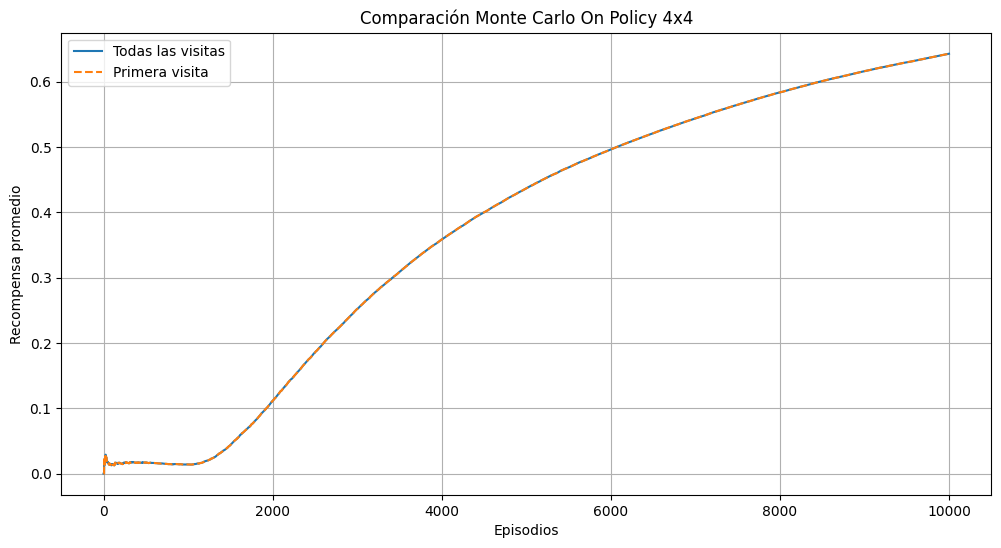

Máxima proporcion Monte Carlo todas las visitas: 0.64291
Máxima proporcion Monte Carlo primera visita: 0.64291


In [13]:
# @title Recompensa promedio Monte Carlo On-Policy en el escenario 4x4

crear_grafica_recompensa_promedio(
    recompensa_1 = media_recompensas_On_V4_all, 
    recompensa_2 = media_recompensas_On_V4_first, 
    label1 = "Todas las visitas", 
    label2 = "Primera visita", 
    titulo = "Comparación Monte Carlo On Policy 4x4")

print(f"Máxima proporcion Monte Carlo todas las visitas: {media_recompensas_On_V4_all[-1]}")
print(f"Máxima proporcion Monte Carlo primera visita: {media_recompensas_On_V4_first[-1]}")

En la gráfica aparece la recompensa promedio a lo largo de 10000 episodios. En una línea naranja corresponde a la recompensa del algoritmo de la primera visita, y en azul a la de todas las visitas.

La recompensa de ambos algoritmos es muy similar durante todo el entrenamiento. Al inicio la recompensa es muy poca, y a partir de unos 1000 episodios empieza a crecer de forma constante, hasta el final, donde el 64% de las ocasiones se ha llegado a la meta.

A continuación, se muestra la evolución de la longitud de los episodios a lo largo del entrenamiento.

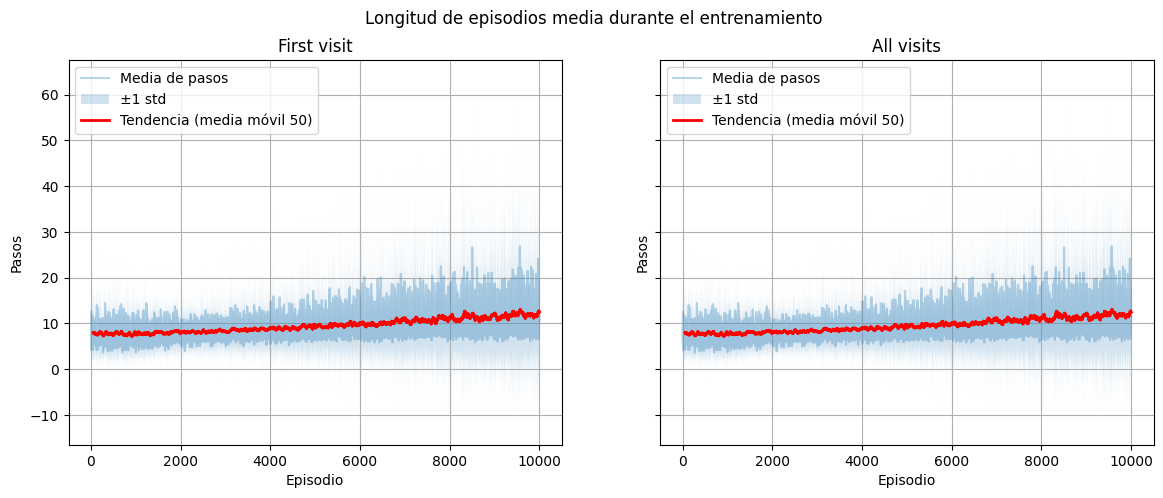

In [14]:
# @title Longitud de los episodios Monte Carlo On-Policy en el escenario 4x4
plot_lengths_mean_std(
    mean_lengths1 = media_longitudes_On_V4_first, 
    mean_lengths2 = media_longitudes_On_V4_all, 
    std_lengths1 = std_longitudes_On_V4_first, 
    std_lengths2 = std_longitudes_On_V4_all, 
    label1 = "First visit", 
    label2 = "All visits", 
    window_size=50, 
    titulo="Longitud de episodios media durante el entrenamiento")

La longitud media de los episodios se mantiene casi constante durante la mayor parte del aprendizaje, con un ligero incremento a medida que avanzan los episodios. La varianza también aumenta conforme avanza el entrenamiento. Esto puede deberse a que, al inicio, muchos episodios terminan pronto porque el agente cae en agujeros con frecuencia, y cuando empieza a aprender a evitarlos, en algunas ocasiones tarda más pasos en llegar a la meta.

A continuación, se muestra la política greedy de ambos algoritmos, obtenida a partir de la media de las tablas Q de todas las semillas.

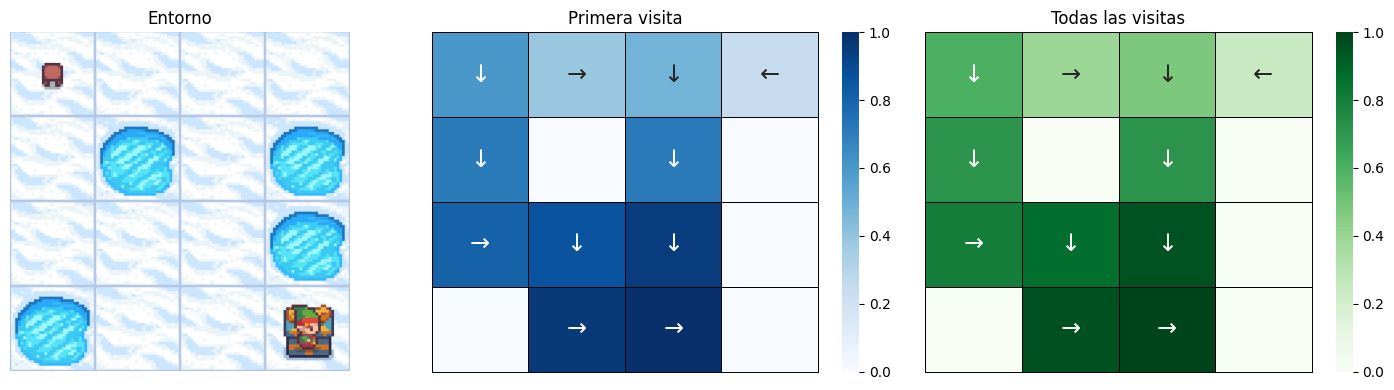

In [15]:
# @title Mostrar el entorno y las políticas greedy de Monte Carlo On-Policy en el escenario 4x4
mostrar_entorno_y_politicas(
    env=env4,
    qtable_1=tabla_Q_media_On_V4_first,
    titulo_1="Primera visita",
    qtable_2=tabla_Q_media_On_V4_all,
    titulo_2="Todas las visitas",
    map_size=4
)

Como se puede observar, los agujeros no tienen una acción asignada porque una vez el agente cae en un agujero, finaliza el episodio. Ocurre lo mismo con la meta.

Por otra parte, ambos algoritmos aprenden los mismos caminos. La intensidad del color de las casillas es mayor en los estados más cercanos a la meta, reflejando que la recompensa esperada de ese estado es mayor. Esta intensidad de color no se debe tanto al factor de descuento utilizado en el aprendizaje, que disminuye la recompensa cuantó más alejado del estado que ha dado esta recompensa, pero al ser 0.99 no se nota visualmente en tan pocos pasos. 

Esto se debe a que, dado que se usa una política que aprendió con epsilon-decaimiento, los estados más alejados de la meta tienen más probabilidad de tomar acciones que les lleven a caer en un agujero por la fase exploratoria.

#### **3.1.2 Algoritmo Montecarlo Off Policy**

Se entrena el algoritmo Monte Carlo off‑policy en el escenario 4x4, utilizando tanto la variante de primera visita como la de todas las visitas.

In [16]:
# @title Aprendizaje Monte Carlo Off-Policy en el escenario 4x4

# Monte Carlo todas las visitas
print("Ejecución de Monte Carlo de todas las visitas:")

media_longitudes_Off_V4_all, std_longitudes_Off_V4_all, media_recompensas_Off_V4_all, tabla_Q_media_Off_V4_all = entrenar_agente(policy = "off_policy", visit = "all_visit", tipo_entorno = "4x4")

# Monte Carlo con primera visita
print("-"*20)
print("Ejecución de Monte Carlo de la primera visita:")

media_longitudes_Off_V4_first, std_longitudes_Off_V4_first, media_recompensas_Off_V4_first, tabla_Q_media_Off_V4_first = entrenar_agente(policy = "off_policy", visit = "first_visit", tipo_entorno = "4x4")

Ejecución de Monte Carlo de todas las visitas:


100%|██████████| 10000/10000 [00:01<00:00, 5758.96it/s]


--------------------
Ejecución de Monte Carlo de la primera visita:


100%|██████████| 10000/10000 [00:01<00:00, 6241.21it/s]


Después del entrenamiento se representa la recompensa promedio por episodio para ambas configuraciones.

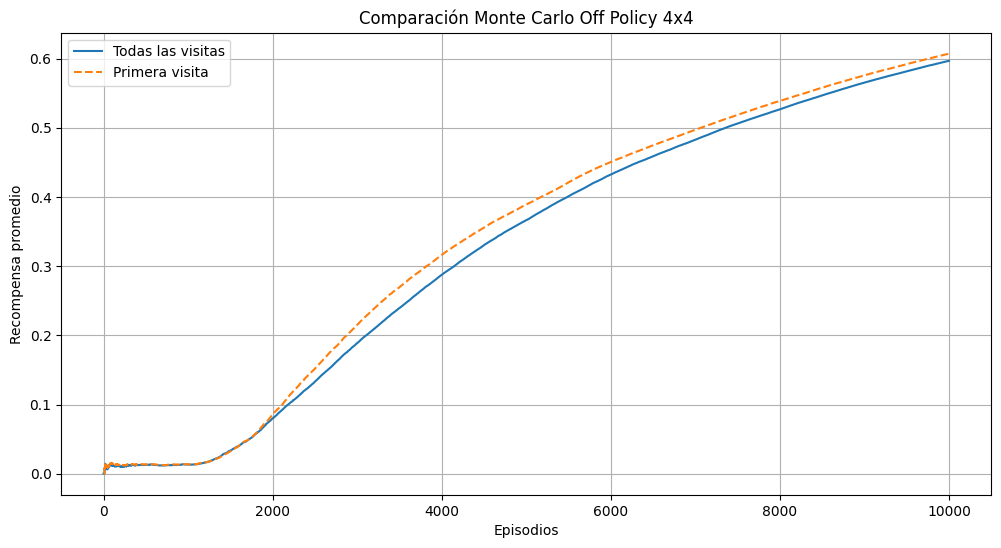

Máxima proporcion Monte Carlo todas las visitas: 0.5966899999999999
Máxima proporcion Monte Carlo primera visita: 0.60696


In [17]:
# @title Recompensa promedio Monte Carlo Off-Policy en el escenario 4x4

crear_grafica_recompensa_promedio(
    recompensa_1 = media_recompensas_Off_V4_all, 
    recompensa_2 = media_recompensas_Off_V4_first, 
    label1 = "Todas las visitas", 
    label2 = "Primera visita", 
    titulo = "Comparación Monte Carlo Off Policy 4x4")

print(f"Máxima proporcion Monte Carlo todas las visitas: {media_recompensas_Off_V4_all[-1]}")
print(f"Máxima proporcion Monte Carlo primera visita: {media_recompensas_Off_V4_first[-1]}")

Se vuelve a observar una recompensa media muy baja al inicio, que a partir de unos 1000 pasos aumenta conforme avanza el entrenamiento. La variante que utiliza el método de la primera visita consigue una recompensa promedio algo mayor antes que la de todas las visitas, pero esta recompensa se hace más pequeña conforme se llega al final de la gráfica (10000 episodios).

A continuación, se muestra la evolución de la longitud de los episodios a lo largo del entrenamiento.

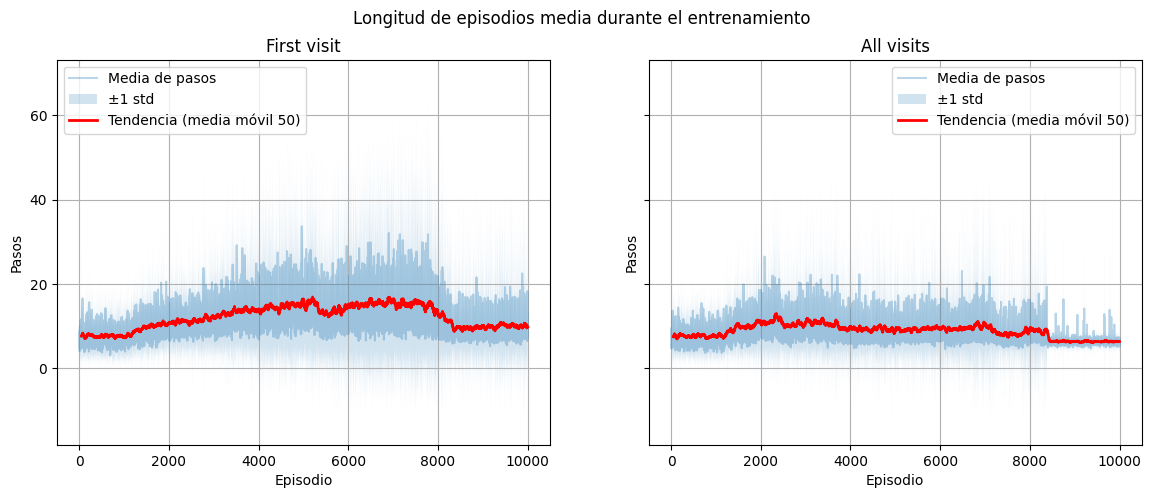

In [18]:
# @title Longitud de los episodios Monte Carlo Off-Policy en el escenario 4x4
plot_lengths_mean_std(
    mean_lengths1 = media_longitudes_Off_V4_first, 
    mean_lengths2 = media_longitudes_Off_V4_all, 
    std_lengths1 = std_longitudes_Off_V4_first, 
    std_lengths2 = std_longitudes_Off_V4_all, 
    label1 = "First visit", 
    label2 = "All visits", 
    window_size=50, 
    titulo="Longitud de episodios media durante el entrenamiento")

La longitud media de los episodios aumenta muy levemente al inicio y se observa una varianza alta. Hacia el final del entrenamiento, en torno a los 9000 episodios, la varianza disminuye y la longitud baja un poco.

Se piensa que ocurre algo parecido a lo visto antes, al principio muchos episodios terminan pronto porque el agente cae en agujeros con frecuencia, y cuando empieza a aprender a evitarlos, en algunas ocasiones tarda más pasos en llegar a la meta. Cuando aprende caminos más cortos a la meta, la longitud media vuelve a reducirse.  ya que muchos episodios terminan pronto porque el agente cae en agujeros con frecuencia, y cuando empieza a aprender a evitarlos, en algunas ocasiones tarda más pasos en llegar a la meta. Al aprender a llegar a la meta en una menor longitud, se baja la longitud media.

Por último, se observa una varianza un poco mayor en el algoritmo de la primera visita que en el de todas las visitas.

A continuación, se muestra la política greedy de ambos algoritmos, obtenida a partir de la media de las tablas Q de todas las semillas.

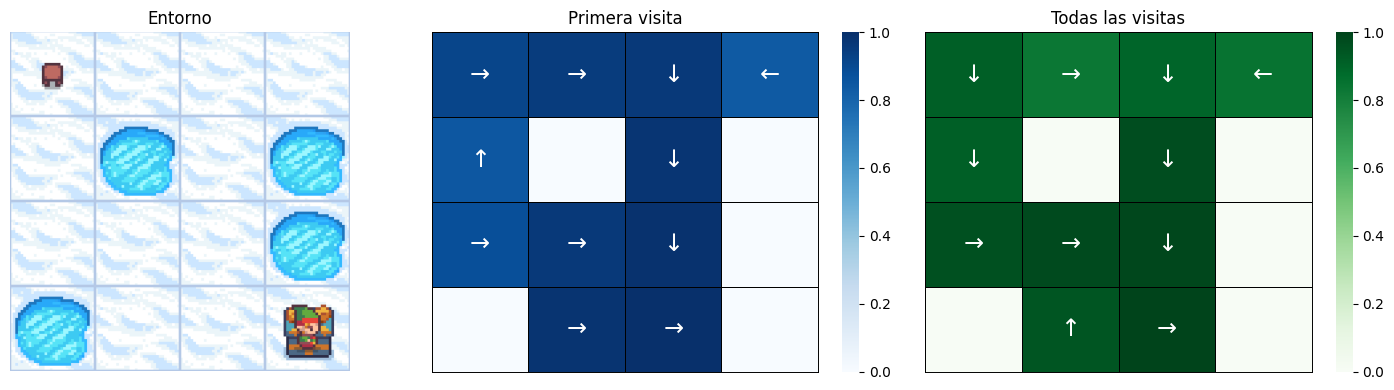

In [19]:
# @title Mostrar el entorno y las políticas greedy de Monte Carlo Off-Policy en el escenario 4x4
mostrar_entorno_y_politicas(
    env=env4,
    qtable_1=tabla_Q_media_Off_V4_first,
    titulo_1="Primera visita",
    qtable_2=tabla_Q_media_Off_V4_all,
    titulo_2="Todas las visitas",
    map_size=4
)

Como se puede observar, los agujeros no tienen una acción asignada porque una vez se cae en un agujero, finaliza el episodio. Ocurre lo mismo con la meta, dado que también es un estado terminal.

Por otra parte, los algoritmos no aprenden los mismos caminos, pero ambos aprenden un camino a la meta. A su vez, los algoritmos muestran el mismo nivel de confianza visible en casi todos los estados. Dado que el factor de confianza es 0.99, no es visible la disminución en pocos pasos.

#### **3.1.3 on-policy vs off-policy**

Por último, se compara el aprendizaje off‑policy y on‑policy. Dado que on‑policy obtiene resultados similares tanto en la variante de todas las visitas como en la de primera visita, y off‑policy presenta resultados ligeramente mejores en la variante de primera visita, la comparación se centra en estas dos configuraciones.

Se representa la recompensa promedio por episodio para ambas configuraciones.

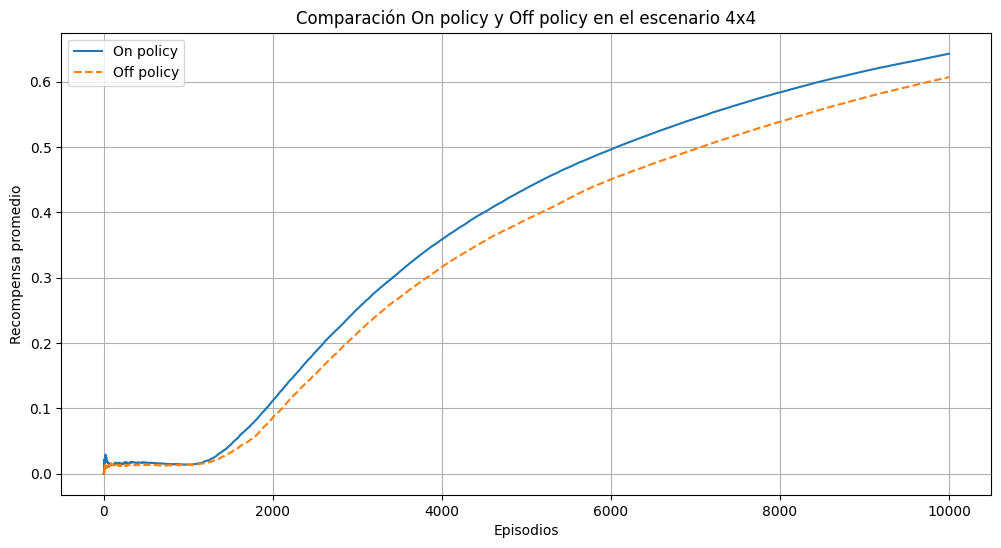

Máxima proporcion Monte Carlo on policy: 0.64291
Máxima proporcion Monte Carlo off policy: 0.60696


In [20]:
# @title Recompensa promedio Monte Carlo Off/On-Policy en el escenario 4x4

crear_grafica_recompensa_promedio(
    recompensa_1 = media_recompensas_On_V4_first, 
    recompensa_2 = media_recompensas_Off_V4_first, 
    label1 = "On policy", 
    label2 = "Off policy", 
    titulo = "Comparación On policy y Off policy en el escenario 4x4")

print(f"Máxima proporcion Monte Carlo on policy: {media_recompensas_On_V4_first[-1]}")
print(f"Máxima proporcion Monte Carlo off policy: {media_recompensas_Off_V4_first[-1]}")

Aunque ambas curvas siguen una forma muy parecida, on‑policy logra recompensas promedio mayores a lo largo del entrenamiento

A continuación, se muestra la evolución de la longitud de los episodios a lo largo del entrenamiento.

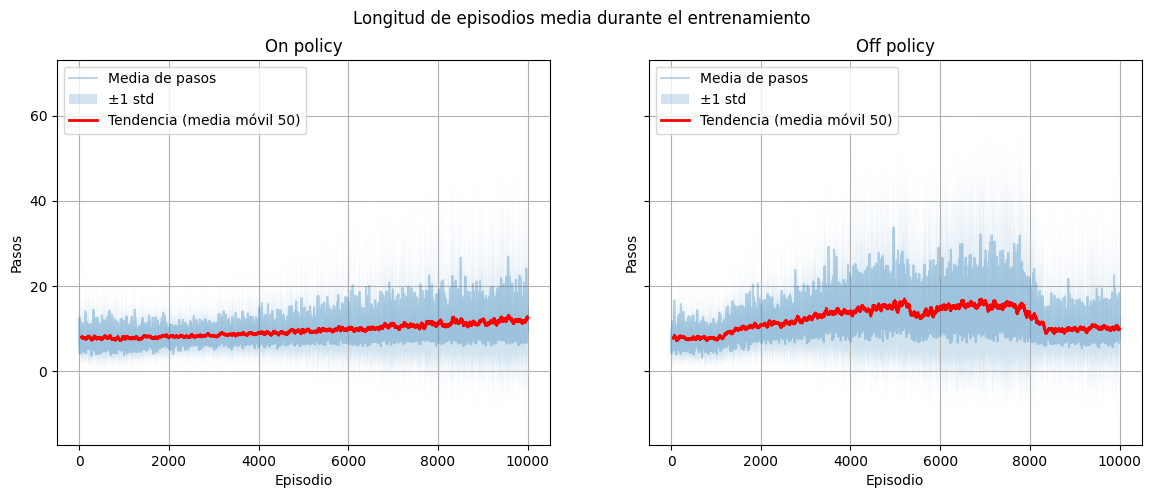

In [21]:
# @title Longitud de los episodios Monte Carlo Off/On-Policy en el escenario 4x4
plot_lengths_mean_std(
    mean_lengths1 = media_longitudes_On_V4_first, 
    mean_lengths2 = media_longitudes_Off_V4_first, 
    std_lengths1 = std_longitudes_On_V4_first, 
    std_lengths2 = std_longitudes_Off_V4_first, 
    label1 = "On policy", 
    label2 = "Off policy", 
    window_size=50, 
    titulo="Longitud de episodios media durante el entrenamiento")

En ambos casos, la longitud media de los episodios se mantiene en un rango parecido, pero en la variante Off policy aumenta al inicio y disminuye al final, mientras que en on‑policy crece de forma más suave.

A continuación, se muestra la política greedy de ambos algoritmos, obtenida a partir de la media de las tablas Q de todas las semillas.

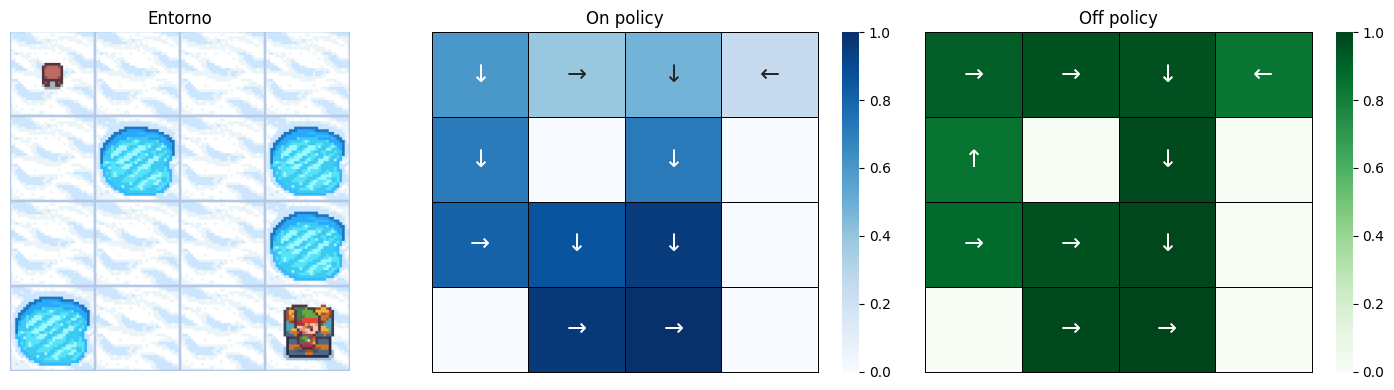

In [22]:
# @title Mostrar el entorno y las políticas greedy de Monte Carlo Off/On-Policy en el escenario 4x4
mostrar_entorno_y_politicas(
    env=env4,
    qtable_1=tabla_Q_media_On_V4_first,
    titulo_1="On policy",
    qtable_2=tabla_Q_media_Off_V4_first,
    titulo_2="Off policy",
    map_size=4
)

Aunque ambos métodos aprenden el camino a la meta, en on policy la política con epsilon-decaimiento durante el entrenamiento explora y a veces cae en agujeros, de modo que los estados más alejados de la meta han acumulado más episodios fallidos y aparecen con un color más claro.

En off policy ocurre lo mismo con la política de epsilon decaimiento, pero sólo se actualizan los valores cuando la acción coincide con la política objetivo, que se corresponde con una política greedy. Por esto, off policy se nota menos la diferencia de intensidad en los colores.

### **3.2 Experimentación en el escenario 8x8**

A continuación, se realiza la experimentación del escenario 8x8.

#### **3.2.1 Algoritmo Montecarlo On Policy**

Se entrena el algoritmo Monte Carlo on‑policy en el escenario 8x8, utilizando tanto la variante de primera visita como la de todas las visitas.

In [23]:
# @title Aprendizaje Monte Carlo On-Policy en el escenario 8x8

# Monte Carlo todas las visitas
print("Ejecución de Monte Carlo de todas las visitas:")

media_longitudes_On_V8_all, std_longitudes_On_V8_all, media_recompensas_On_V8_all, tabla_Q_media_On_V8_all = entrenar_agente(policy = "on_policy", visit = "all_visit", tipo_entorno = "8x8")

# Monte Carlo con primera visita
print("-"*20)
print("Ejecución de Monte Carlo de la primera visita:")

media_longitudes_On_V8_first, std_longitudes_On_V8_first, media_recompensas_On_V8_first, tabla_Q_media_On_V8_first = entrenar_agente(policy = "on_policy", visit = "first_visit", tipo_entorno = "8x8")

Ejecución de Monte Carlo de todas las visitas:


100%|██████████| 50000/50000 [00:26<00:00, 1857.39it/s]


--------------------
Ejecución de Monte Carlo de la primera visita:


100%|██████████| 50000/50000 [00:26<00:00, 1866.57it/s]


Después del entrenamiento se representa la recompensa promedio por episodio para ambas configuraciones.

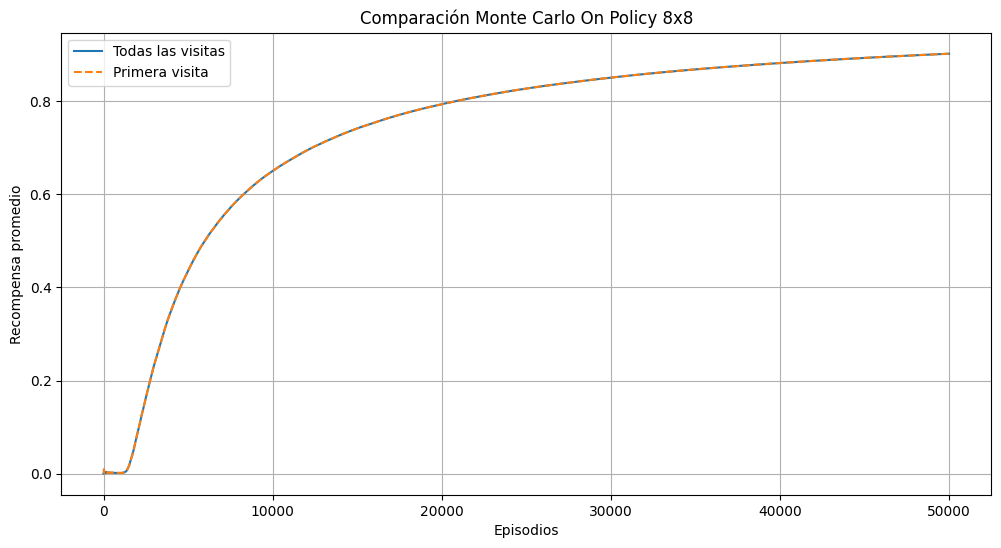

Máxima proporcion Monte Carlo todas las visitas: 0.902082
Máxima proporcion Monte Carlo primera visita: 0.902082


In [24]:
# @title Recompensa promedio Monte Carlo On-Policy en el escenario 8x8

crear_grafica_recompensa_promedio(
    recompensa_1 = media_recompensas_On_V8_all, 
    recompensa_2 = media_recompensas_On_V8_first, 
    label1 = "Todas las visitas", 
    label2 = "Primera visita", 
    titulo = "Comparación Monte Carlo On Policy 8x8")

print(f"Máxima proporcion Monte Carlo todas las visitas: {media_recompensas_On_V8_all[-1]}")
print(f"Máxima proporcion Monte Carlo primera visita: {media_recompensas_On_V8_first[-1]}")

En la gráfica aparece la recompensa promedio a lo largo de 50000 episodios. En una línea naranja aparece la recompensa del algoritmo de la primera visita, y en azul el algoritmo de todas las visitas.

La recompensa de ambos algoritmos es muy similar durante todo el entrenamiento. Al inicio, la recompensa es muy poca, y a partir de unos 1000 episodios empieza a crecer, con un crecimiento más elevado al inicio que al final, hasta los 50000 episodios, donde el 90% de las ocasiones se ha llegado a la meta.

A continuación, se muestra la evolución de la longitud de los episodios a lo largo del entrenamiento.

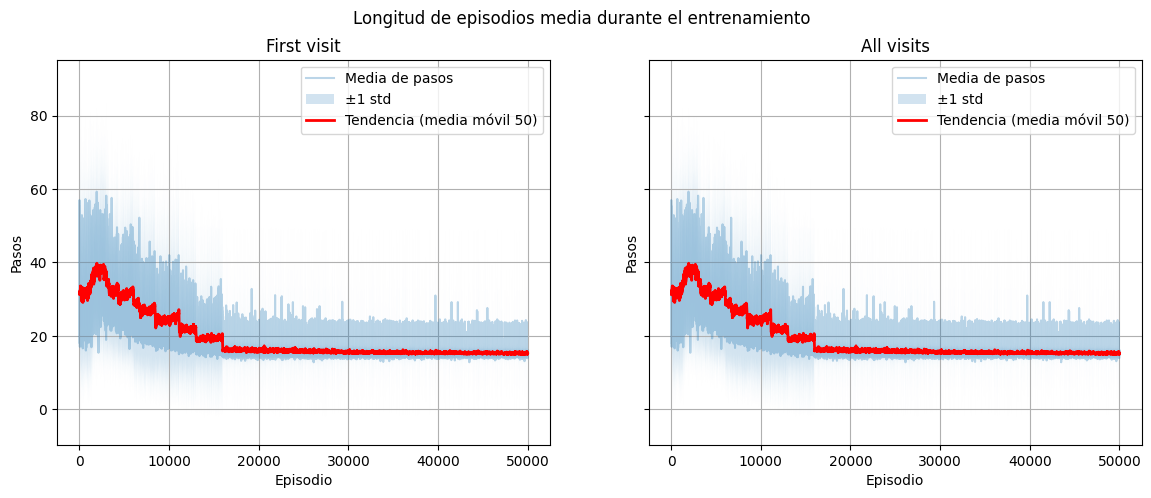

In [25]:
# @title Longitud de los episodios Monte Carlo On-Policy en el escenario 8x8
plot_lengths_mean_std(
    mean_lengths1 = media_longitudes_On_V8_first, 
    mean_lengths2 = media_longitudes_On_V8_all, 
    std_lengths1 = std_longitudes_On_V8_first, 
    std_lengths2 = std_longitudes_On_V8_all, 
    label1 = "First visit", 
    label2 = "All visits", 
    window_size=50, 
    titulo="Longitud de episodios media durante el entrenamiento")

La longitud de los episodios media es más elevada al inicio y desciende de forma escalonada hasta aproximadamente el episodio 1500. A partir de este, tanto la varianza como la longitud media de los episodios se mantiene prácticamente onstante.

A continuación, se muestra la política greedy de ambos algoritmos, obtenida a partir de la media de las tablas Q de todas las semillas.

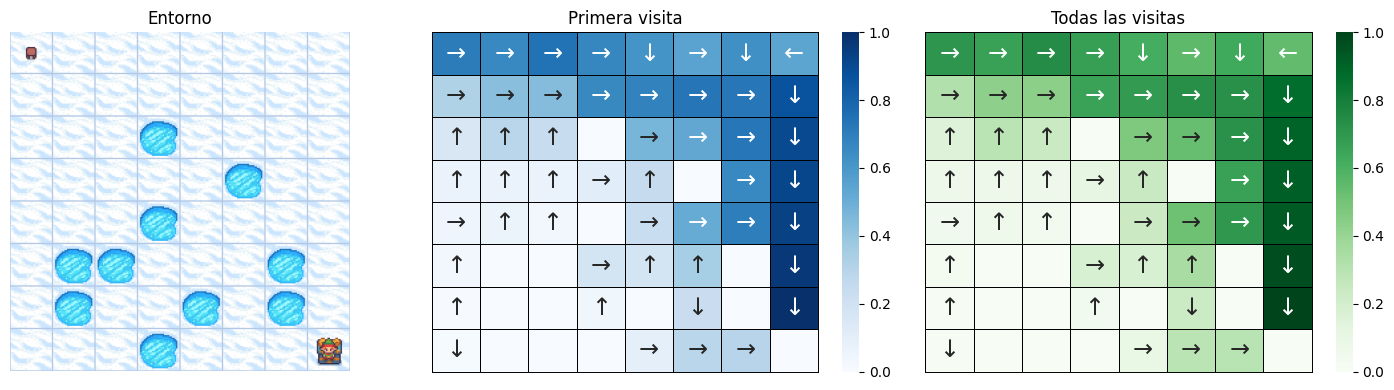

In [26]:
# @title Mostrar el entorno y las políticas greedy de Monte Carlo On-Policy en el escenario 8x8
mostrar_entorno_y_politicas(
    env=env8,
    qtable_1=tabla_Q_media_On_V8_first,
    titulo_1="Primera visita",
    qtable_2=tabla_Q_media_On_V8_all,
    titulo_2="Todas las visitas",
    map_size=8
)

Como se puede observar, los agujeros no tienen una acción asignada porque una vez se cae en un agujero, finaliza el episodio. Ocurre lo mismo con la meta. Otros que no son ni agujeros ni la meta tampoco tienen acciones asignadas, seguramente porque están tan alejados del inicio y de la meta que pocas veces se llega a estos estados.

Por otra parte, se observa como ambos algoritmos aprenden los mismos caminos. A su vez, cuanto más cerca se encuentra de la meta más color tiene el estado, con un cambio de intensidad de color muy leve, dado que el factor de descuento utilizado en el aprendizaje disminuye la recompensa cuantó más alejado del estado que ha dado esta recompensa, pero al ser 0.99 se aprecia poco.

Por otro lado, cuanto más cerca se está de los agujeros, menor es la intensidad del color. Esto se debe a que, dado que se usa una política que aprendió con epsilon-decaimiento, en las zonas alejadas de la meta es más probable que durante la fase de exploración se hayan tomado acciones que terminen en agujeros, lo que reduce el valor estimado de esos pares estado-acción.

#### **3.2.2 Algoritmo Montecarlo Off policy**

Se entrena el algoritmo Monte Carlo off‑policy en el escenario 8x8, utilizando tanto la variante de primera visita como la de todas las visitas.

In [27]:
# @title Aprendizaje Monte Carlo Off-Policy en el escenario 8x8

# Monte Carlo todas las visitas
print("Ejecución de Monte Carlo de todas las visitas:")

media_longitudes_Off_V8_all, std_longitudes_Off_V8_all, media_recompensas_Off_V8_all, tabla_Q_media_Off_V8_all = entrenar_agente(policy = "off_policy", visit = "all_visit", tipo_entorno = "8x8")

# Monte Carlo con primera visita
print("-"*20)
print("Ejecución de Monte Carlo de la primera visita:")

media_longitudes_Off_V8_first, std_longitudes_Off_V8_first, media_recompensas_Off_V8_first, tabla_Q_media_Off_V8_first = entrenar_agente(policy = "off_policy", visit = "first_visit", tipo_entorno = "8x8")

Ejecución de Monte Carlo de todas las visitas:


100%|██████████| 50000/50000 [00:20<00:00, 2417.48it/s]


--------------------
Ejecución de Monte Carlo de la primera visita:


100%|██████████| 50000/50000 [00:18<00:00, 2695.56it/s]


Después del entrenamiento se representa la recompensa promedio por episodio para ambas configuraciones.

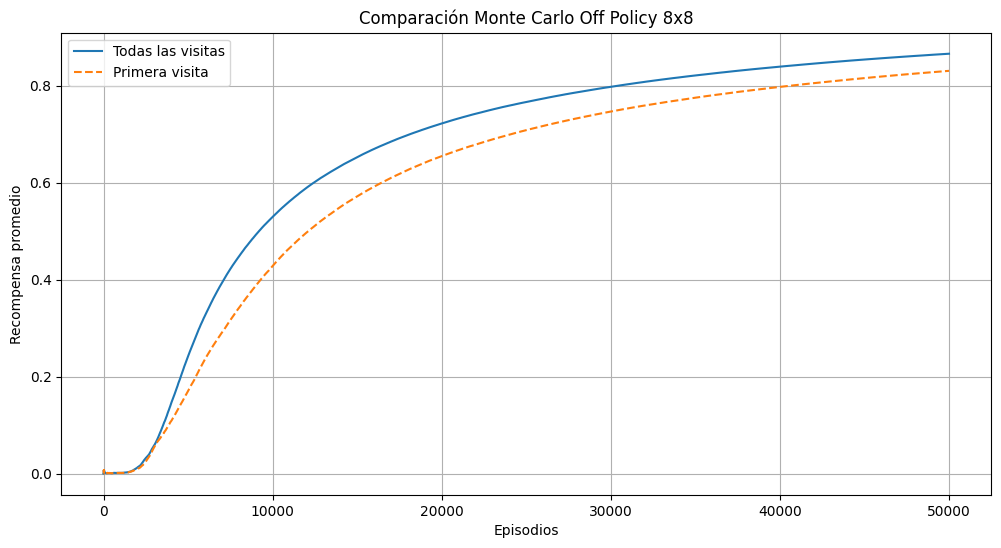

Máxima proporcion Monte Carlo todas las visitas: 0.8661299999999998
Máxima proporcion Monte Carlo primera visita: 0.830838


In [28]:
# @title Recompensa promedio Monte Carlo Off-Policy en el escenario 8x8

crear_grafica_recompensa_promedio(
    recompensa_1 = media_recompensas_Off_V8_all, 
    recompensa_2 = media_recompensas_Off_V8_first, 
    label1 = "Todas las visitas", 
    label2 = "Primera visita", 
    titulo = "Comparación Monte Carlo Off Policy 8x8")

print(f"Máxima proporcion Monte Carlo todas las visitas: {media_recompensas_Off_V8_all[-1]}")
print(f"Máxima proporcion Monte Carlo primera visita: {media_recompensas_Off_V8_first[-1]}")

Se vuelve a observar una recompensa media muy baja al inicio, que rápidamente aumenta conforme avanza el entrenamiento. La variante que utiliza el método de todas las visitas consigue una recompensa promedio algo mayor antes que la de la primera visita, pero esta ventaja se reduce conforme se llega al final de la gráfica (50000 episodios).

A continuación, se muestra la evolución de la longitud de los episodios a lo largo del entrenamiento.

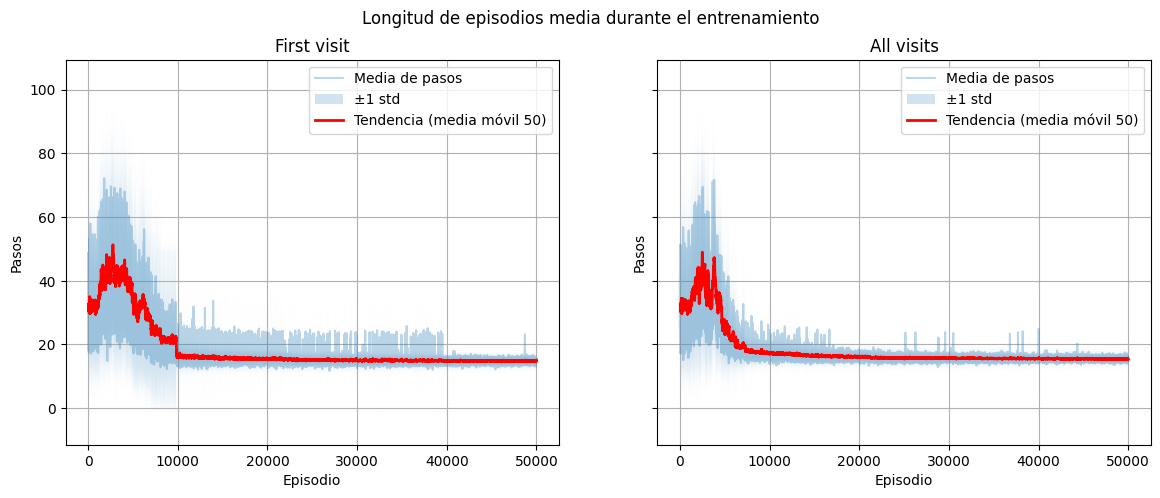

In [29]:
# @title Longitud de los episodios Monte Carlo Off-Policy en el escenario 8x8
plot_lengths_mean_std(
    mean_lengths1 = media_longitudes_Off_V8_first, 
    mean_lengths2 = media_longitudes_Off_V8_all, 
    std_lengths1 = std_longitudes_Off_V8_first, 
    std_lengths2 = std_longitudes_Off_V8_all, 
    label1 = "First visit", 
    label2 = "All visits", 
    window_size=50, 
    titulo="Longitud de episodios media durante el entrenamiento")

La longitud media de los episodios es más elevada al inicio, aumenta ligeramente y después disminuye antes de los 1000 episodios. Esto podría deberse a que al inicio debe aprender a no caer en agujeros, lo que incrementa el número de pasos, pero cuando se evitan se aprende a llegar a la meta en un menor número de pasos. Esto es consistente con la anterior gráfica, en la que en los primeros mil episodios aumenta considerablemente la recompensa promedio (cantidad de veces que se llega a la meta) en ambos algoritmos.

El algoritmo de todas las visitas logra menor variabilidad a partir de los 1000 episodios. En ambos casos, la variabilidad disminuye desde el inicio hasta el final del entrenamiento, aunque en el método de todas las visitas esta variabilidad disminuye antes.

A continuación, se muestra la política greedy de ambos algoritmos, obtenida a partir de la media de las tablas Q de todas las semillas.

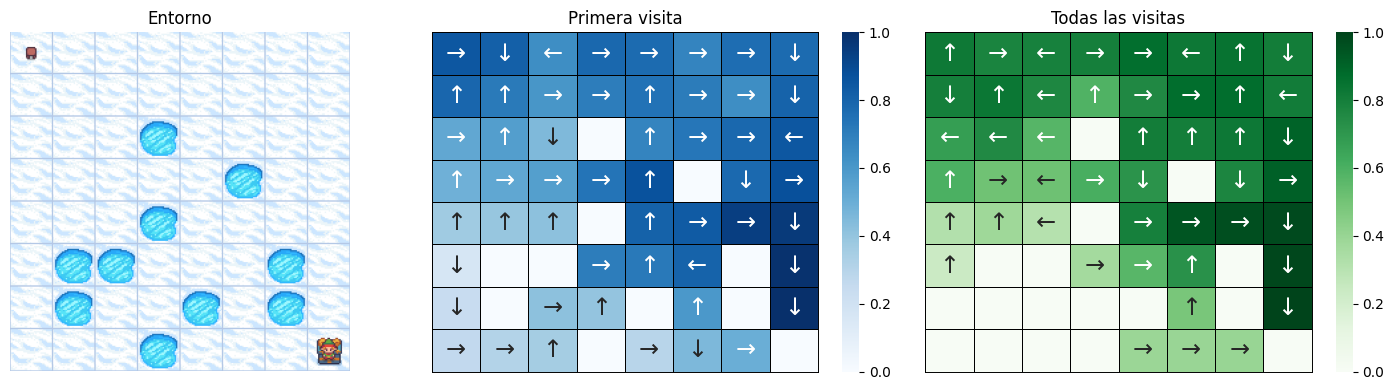

In [30]:
# @title Mostrar el entorno y las políticas greedy de Monte Carlo Off-Policy en el escenario 8x8
mostrar_entorno_y_politicas(
    env=env8,
    qtable_1=tabla_Q_media_Off_V8_first,
    titulo_1="Primera visita",
    qtable_2=tabla_Q_media_Off_V8_all,
    titulo_2="Todas las visitas",
    map_size=8
)

Aunque los algoritmos aprenden un camino hacia la meta, al representar la media sobre todos los agentes entrenados con las 10 semillas distintas aparecen algunos bucles (por ejemplo, del estado x al z y del z al x), que se deben al efecto de promediar distintas trayectorias.

En general, se observa una menor recompensa esperada de los pares estado-acción cuanto más alejados están de la meta y cuanto más cercanos están a agujeros.

#### **3.2.3 on-policy vs off-policy**

Por último, se compara el aprendizaje off‑policy y on‑policy. Dado que on‑policy obtiene resultados similares tanto en la variante de todas las visitas como en la de primera visita, y off‑policy presenta resultados ligeramente mejores en la variante de todas las visitas, la comparación se centra en estas dos configuraciones.

Se representa la recompensa promedio por episodio para ambas configuraciones.

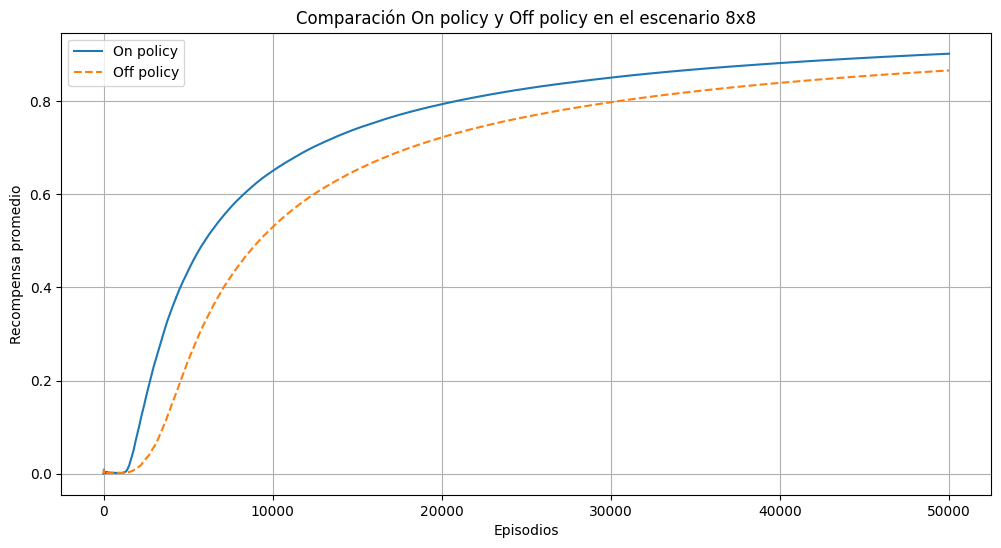

Máxima proporcion Monte Carlo on policy: 0.902082
Máxima proporcion Monte Carlo off policy: 0.8661299999999998


In [34]:
# @title Recompensa promedio Monte Carlo Off/On-Policy en el escenario 8x8

crear_grafica_recompensa_promedio(
    recompensa_1 = media_recompensas_On_V8_all, 
    recompensa_2 = media_recompensas_Off_V8_all, 
    label1 = "On policy", 
    label2 = "Off policy", 
    titulo = "Comparación On policy y Off policy en el escenario 8x8")

print(f"Máxima proporcion Monte Carlo on policy: {media_recompensas_On_V8_all[-1]}")
print(f"Máxima proporcion Monte Carlo off policy: {media_recompensas_Off_V8_all[-1]}")

Aunque ambas curvas siguen una forma muy parecida, on‑policy logra recompensas promedio mayores a lo largo del entrenamiento.

A continuación, se muestra la evolución de la longitud de los episodios a lo largo del entrenamiento.

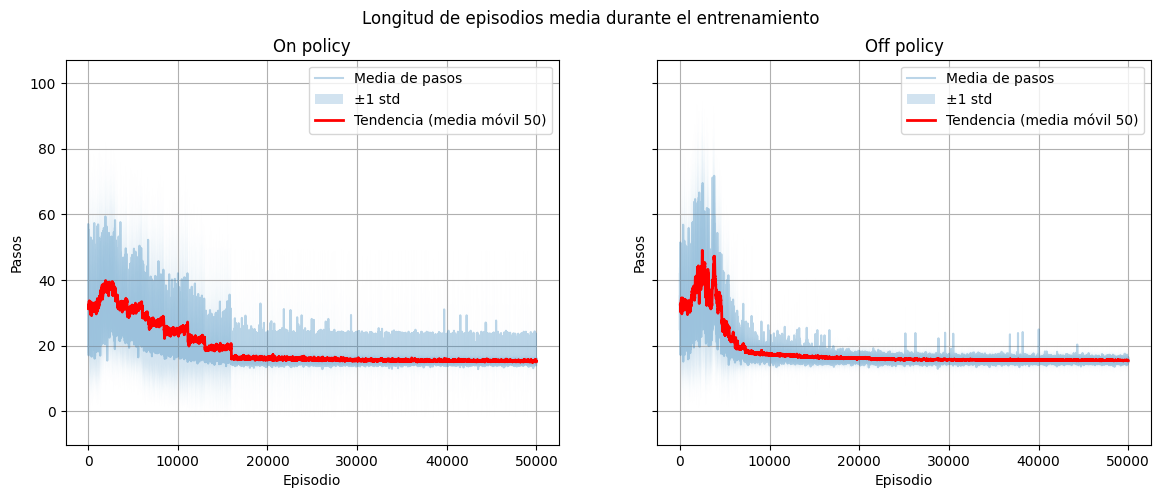

In [35]:
# @title Longitud de los episodios Monte Carlo Off/On-Policy en el escenario 8x8
plot_lengths_mean_std(
    mean_lengths1 = media_longitudes_On_V8_all, 
    mean_lengths2 = media_longitudes_Off_V8_all, 
    std_lengths1 = std_longitudes_On_V8_all, 
    std_lengths2 = std_longitudes_Off_V8_all, 
    label1 = "On policy", 
    label2 = "Off policy", 
    window_size=50, 
    titulo="Longitud de episodios media durante el entrenamiento")

En ambos casos, la longitud media de los episodios se mantiene en un rango parecido, pero en la variante off policy aumenta más al incio y disminuye antes de los 1000 episodios, mientras que en la variante on policy aumenta menos y su bajada se prolonga hasta aproximadamente el episodio 1500.

Tras estos primeros 1500 episodios, la variante off policy tiene menos variabilidad que la on policy.

A continuación, se muestra la política greedy de ambos algoritmos, obtenida a partir de la media de las tablas Q de todas las semillas.

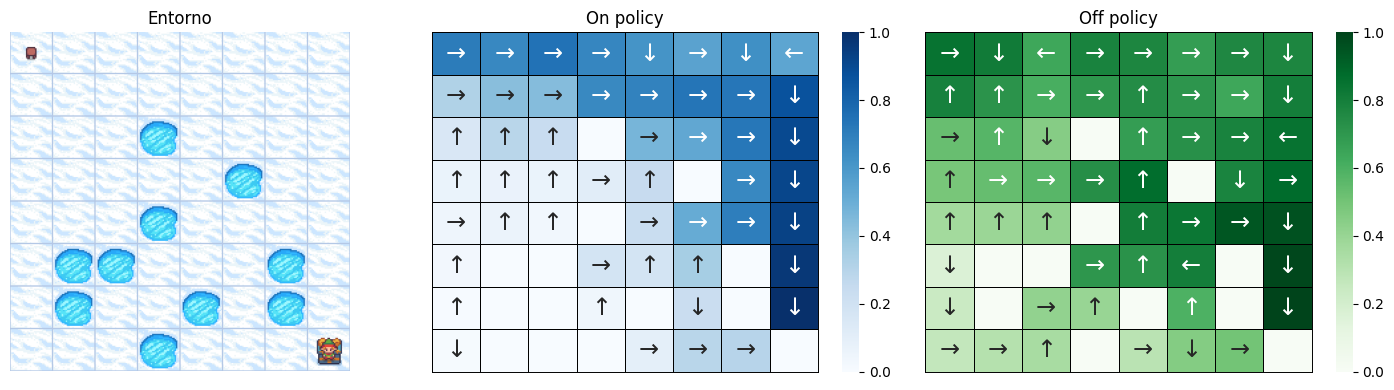

In [33]:
# @title Mostrar el entorno y las políticas greedy de Monte Carlo Off/On-Policy en el escenario 8x8
mostrar_entorno_y_politicas(
    env=env8,
    qtable_1=tabla_Q_media_On_V8_first,
    titulo_1="On policy",
    qtable_2=tabla_Q_media_Off_V8_first,
    titulo_2="Off policy",
    map_size=8
)

Aunque los algoritmos aprenden un camino hacia la meta, vuelven a aparecer algunos bucles por la razón previamente explicada.

En general, se observa una menor recompensa esperada de los pares estado-acción cuanto más alejados están de la meta y cuanto más cercanos están a agujeros.

## **4. Análisis y Estudios Futuros**

### **4.1 Análisis de Resultados**
Se ha observado que, con un número considerable de episodios, todas las variantes consiguen aprender políticas que alcanzan la meta con mucha frecuencia.

En muchos casos las variantes presentan comportamientos muy similares y las diferencias entre primera visita y todas las visitas son casi nulas.

Sin embargo, se ha observado una recompensa media algo mayor en on policy que en off policy al inicio, diferencia que disminuye conforme avanzan los episodios. Esto podría deberse a que on policy actualiza con todas las experiencias, mientras que off policy no actualiza si la acción tomada no coincide con la de la política objetivo. Por lo tanto, al tener menos actualizaciones, tarda más en alcanzar la meta.

### **4.2 Propuestas para Estudios Futuros**

Como propuesta para estudios futuros, se propone la prueba de estos algoritmos en el entorno resbaladizo, donde se podría mostrar más la diferencia entre las distintas variantes.